# **Advancing Bengali NLP: Sentiment and Emotion Analysis**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('/content/Advancing Bengali NLP for Sentiment and Emotion Dataset.xlsx')
pd.set_option('display.max_colwidth', None)
df.head()

,Text,Sentiment,Emotion
0,"এসব পাছা কবিরের আজাইররা পোস্ট। হেতি ক, ""যদি ভুল করে থাকি!! "" কত্ত বড় হারামজাদি ইতে!! উষ্ঠা মারা উচিত হেতিরে।",Negative,Creepy
1,জুতা মারি গরুদান মারান!! আপনার আম্মা আব্বার খেলা দেখে কি সিউর হইছিলেন আপনি তাদেরই মেয়ে???,Strongly Negative,Creepy
2,"সুখে থাকতে ভুতে কিলাই, প্রবাদটা এর কাজের দ্বারা আবারো প্রমানিত। এর অভিযোগের বাস্তবতা ওরে দিয়েই বাস্তবায়ন করা হোক।",Negative,Bullying
3,তর মাথায় ব্রেন আছে সেটা তুই দেখছস? না দেখলে ভাব্বি গবর আছে,Strongly Negative,Bullying
4,আপনি কি নাস্তিক..?,Negative,Unbiased


In [3]:
print("\nColumns:", df.columns.tolist())


Columns: ['Text', 'Sentiment', 'Emotion']


In [4]:
print("DATASET INFO")
print("." * 50)
print(f"Total rows     : {len(df)}")
print(f"Total columns  : {df.shape[1]}")
print(f"Null values    :\n{df.isnull().sum()}")
print("." * 50)
print(f"\nDuplicate rows : {df.duplicated().sum()}")
print(f"Duplicate texts: {df['Text'].duplicated().sum()}")
print("." * 50)
print("\nData Types:")
print(df.dtypes)

DATASET INFO
..................................................
Total rows     : 34812
Total columns  : 3
Null values    :
Text         0
Sentiment    0
Emotion      0
dtype: int64
..................................................

Duplicate rows : 26028
Duplicate texts: 28895
..................................................

Data Types:
Text         object
Sentiment    object
Emotion      object
dtype: object


## 1. Dataset Overview and Initial Inspection

A preliminary examination of the dataset was conducted to understand its structure, quality, and overall characteristics. The dataset comprises textual data annotated with both sentiment and emotion labels, enabling multi-level analysis.

### Descriptive Statistics

The key statistical properties of the dataset are summarized below:

- **Total Observations:** 34,812  
- **Total Variables:** 3 (`Text`, `Sentiment`, `Emotion`)  
- **Missing Values:** No missing or null values were identified, ensuring data completeness and reliability for subsequent analysis.  
- **Duplicate Entries:**  
  - A total of **26,028 duplicate rows** were detected.  
  - Additionally, **28,895 duplicate text entries** were observed.  
  - To avoid bias and redundancy, these duplicates will be removed during the data preprocessing phase.


### Summary

Overall, the dataset is structurally simple and complete, with no missing values. However, the presence of a substantial number of duplicate entries necessitates careful preprocessing to ensure the validity and robustness of the analytical results.

In [5]:
print(f"Before: {len(df)} rows")
df = df.drop_duplicates(subset='Text').reset_index(drop=True)
print(f"After removing duplicates: {len(df)} rows")

Before: 34812 rows
After removing duplicates: 5917 rows


### 2. Removing Duplicates Data
Following the removal of duplicate entries, a significant reduction in dataset size was observed:
- **Before Cleaning:** 34,812 rows  
- **After Removing Duplicates:** 5,917 rows
  
This reduction highlights the extent of redundancy present in the original dataset and ensures a more reliable foundation for subsequent analysis.

In [6]:
df['Sentiment'] = df['Sentiment'].str.strip()
df['Emotion'] = df['Emotion'].str.strip()

print("Sentiment unique values:", df['Sentiment'].unique())
print("\nEmotion unique values:", df['Emotion'].unique())

Sentiment unique values: ['Negative' 'Strongly Negative' 'Strongly  Positive' 'Neutral' 'Positive']

Emotion unique values: ['Creepy' 'Bullying' 'Unbiased' 'Joyfull' 'Surprise']


### 3. Label Standardization and Inspection

To ensure consistency in categorical labels, leading and trailing whitespaces were removed from the `Sentiment` and `Emotion` columns. Following this preprocessing step, the unique values within each category were examined.

The distinct labels identified are as follows:

- **Sentiment Categories:**  
  `Negative`, `Strongly Negative`, `Strongly Positive`, `Neutral`, `Positive`

- **Emotion Categories:**  
  `Creepy`, `Bullying`, `Unbiased`, `Joyfull`, `Surprise`

It is noteworthy that minor inconsistencies in labeling (e.g., spacing issues and spelling variations such as *"Joyfull"*) are present, which may require further normalization to ensure uniformity across the dataset.

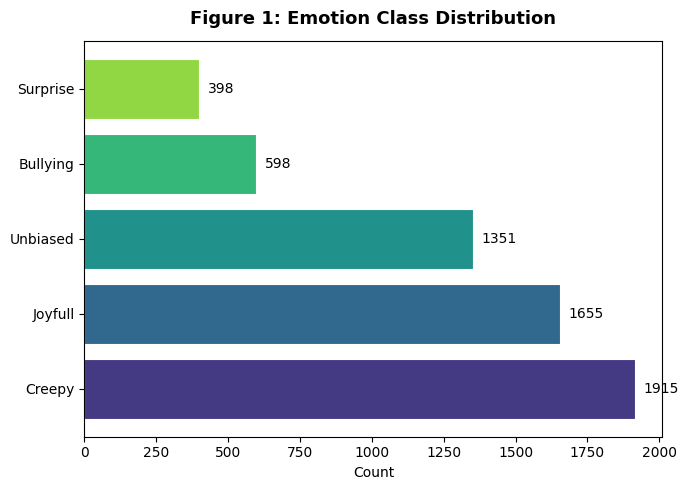

In [7]:
emotion_counts = df['Emotion'].value_counts()
colors_e = sns.color_palette('viridis', len(emotion_counts))

plt.figure(figsize=(7, 5))

plt.barh(emotion_counts.index, emotion_counts.values,
         color=colors_e, edgecolor='white', linewidth=0.8)

plt.title('Figure 1: Emotion Class Distribution', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Count')

for i, v in enumerate(emotion_counts.values):
    plt.text(v + 30, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('emotion_bar_distribution.png', bbox_inches='tight')
plt.show()

### 4. Emotion Class Distribution

The distribution of emotion classes in the dataset is illustrated in Figure 1. The analysis reveals an imbalanced distribution across different emotion categories.

- **Creepy** is the most dominant class, comprising **1,915 instances**.  
- **Joyful** follows with **1,655 instances**, indicating a strong presence of positive emotional expressions.  
- **Unbiased** accounts for **1,351 instances**, representing a moderate portion of the dataset.  
- **Bullying** is less frequent with **598 instances**.  
- **Surprise** is the least represented class, with only **398 instances**.

This imbalance suggests that certain emotion categories are overrepresented, which may influence model performance. Appropriate techniques such as resampling or class weighting may be considered to address this issue during model training.

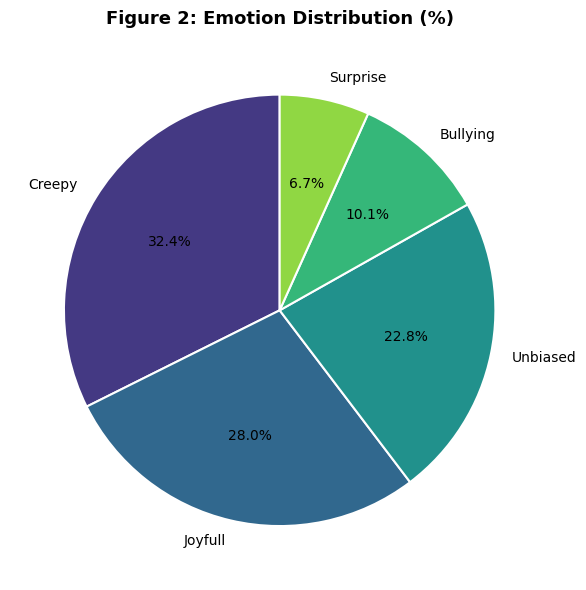

In [8]:
plt.figure(figsize=(19,6))

plt.pie(emotion_counts.values,
        labels=emotion_counts.index,
        autopct='%1.1f%%',
        colors=colors_e,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

plt.title('Figure 2: Emotion Distribution (%)', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('emotion_pie_distribution.png', bbox_inches='tight')
plt.show()

### 5. Emotion Distribution (Percentage)

Figure 2 presents the proportional distribution of emotion classes within the dataset, offering a clearer perspective on class imbalance.

- **Creepy** constitutes the largest share at **32.4%**, indicating a strong dominance in the dataset.  
- **Joyful** accounts for **28.0%**, reflecting a substantial presence of positive emotional expressions.  
- **Unbiased** represents **22.8%**, forming a moderate portion of the data.  
- **Bullying** comprises **10.1%**, indicating relatively lower frequency.  
- **Surprise** is the least represented class at **6.7%**.

The percentage-based representation reinforces the presence of class imbalance observed in the absolute counts. Such imbalance should be carefully addressed in downstream tasks to prevent biased model predictions.


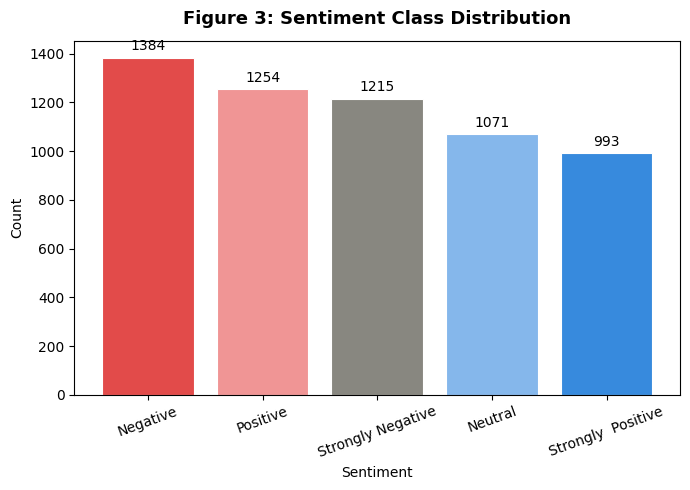

In [9]:
import matplotlib.pyplot as plt

sentiment_counts = df['Sentiment'].value_counts()
colors_s = ['#E24B4A', '#F09595', '#888780', '#85B7EB', '#378ADD']

plt.figure(figsize=(7, 5))

plt.bar(sentiment_counts.index, sentiment_counts.values,
        color=colors_s, edgecolor='white', linewidth=0.8)

plt.title('Figure 3: Sentiment Class Distribution', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=20)

for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('sentiment_bar_distribution.png', bbox_inches='tight')
plt.show()

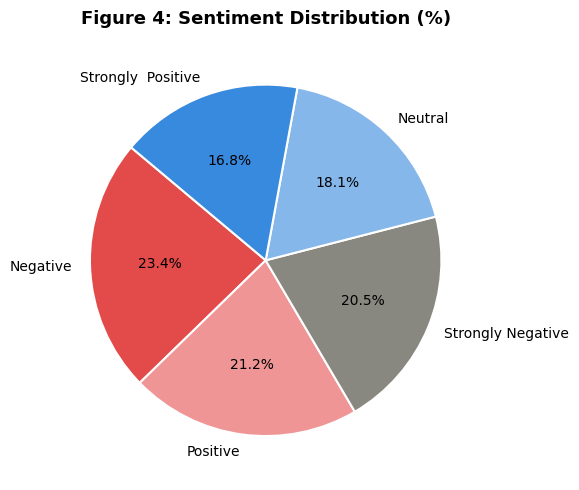

In [10]:
plt.figure(figsize=(7, 5))

plt.pie(sentiment_counts.values,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        colors=colors_s,
        startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

plt.title('Figure 4: Sentiment Distribution (%)', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('sentiment_pie_distribution.png', bbox_inches='tight')
plt.show()

### 6. Sentiment Class Distribution

The distribution of sentiment classes in the dataset is illustrated in Figure 4.

- **Negative** is the most frequent class with **1,384 instances (23.4%)**.
- **Positive** follows with **1,254 instances (21.2%)**.
- **Strongly Negative** accounts for **1,215 instances (20.5%)**.
- **Neutral** contains **1,071 instances (18.1%)**.
- **Strongly Positive** is the least frequent with **993 instances (16.8%)**.

The sentiment classes are **relatively balanced**, with the difference between the most and least frequent class being only ~400 instances. Unlike the emotion distribution, this dataset does not exhibit significant class imbalance. However, minor weighting techniques may still be considered during model training for optimal performance.

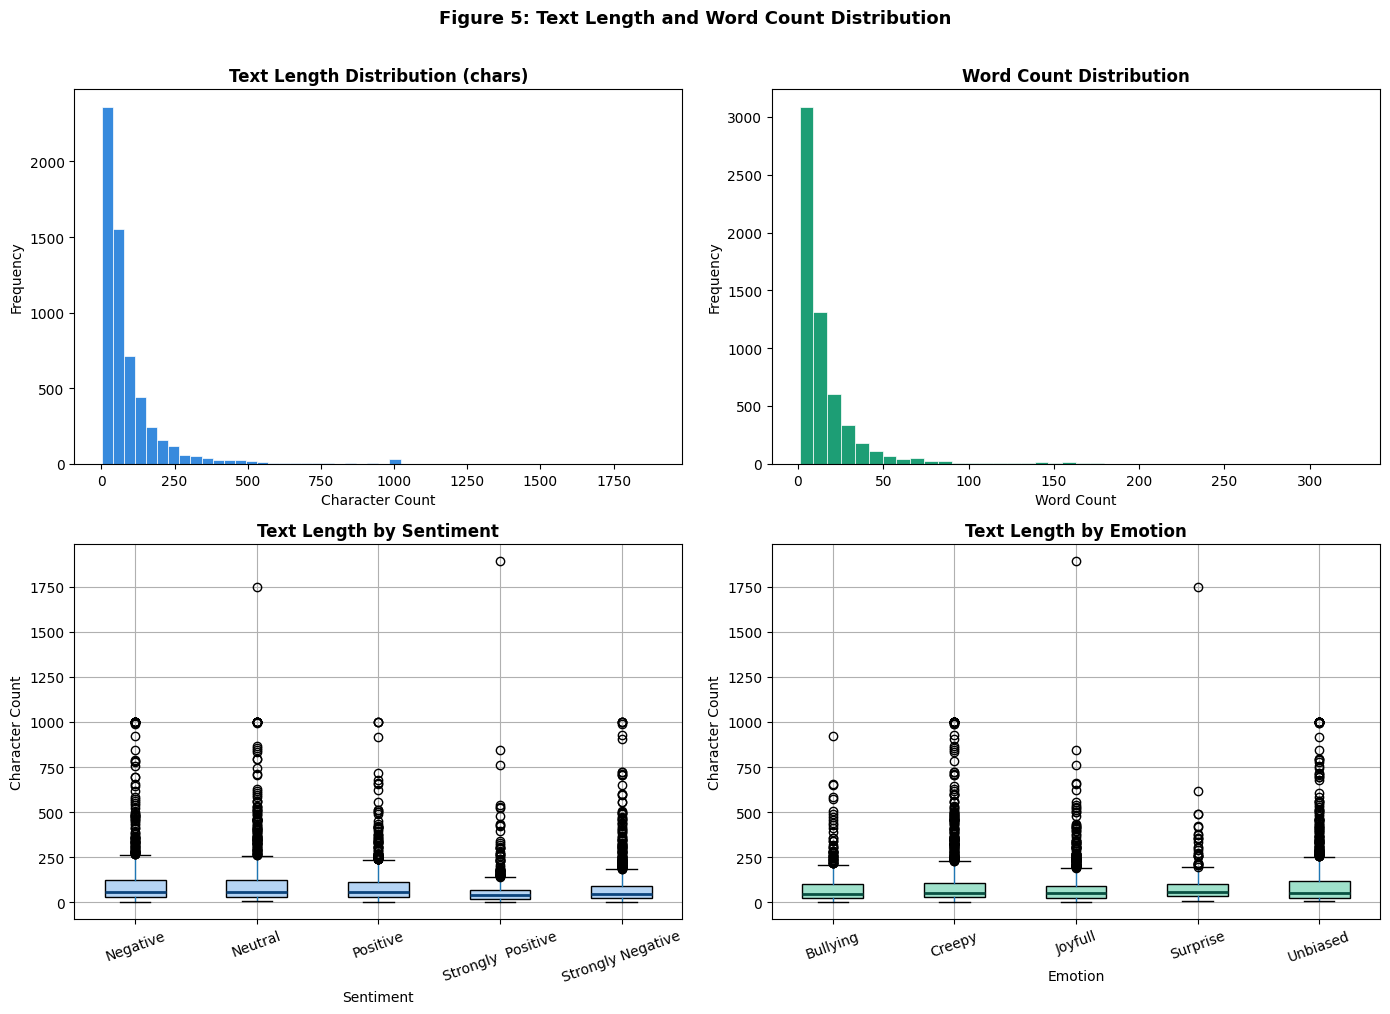


Text Length Stats:
count    5917.0
mean       90.4
std       126.9
min         2.0
25%        26.0
50%        51.0
75%       102.0
max      1891.0
Name: text_length, dtype: float64


In [11]:
df['text_length'] = df['Text'].str.len()
df['word_count'] = df['Text'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))


axes[0][0].hist(df['text_length'], bins=50, color='#378ADD', edgecolor='white', linewidth=0.5)
axes[0][0].set_title('Text Length Distribution (chars)', fontsize=12, fontweight='bold')
axes[0][0].set_xlabel('Character Count')
axes[0][0].set_ylabel('Frequency')

axes[0][1].hist(df['word_count'], bins=40, color='#1D9E75', edgecolor='white', linewidth=0.5)
axes[0][1].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[0][1].set_xlabel('Word Count')
axes[0][1].set_ylabel('Frequency')

df.boxplot(column='text_length', by='Sentiment', ax=axes[1][0],
           patch_artist=True, boxprops=dict(facecolor='#B5D4F4'),
           medianprops=dict(color='#0C447C', linewidth=2))
axes[1][0].set_title('Text Length by Sentiment', fontsize=12, fontweight='bold')
axes[1][0].set_xlabel('Sentiment')
axes[1][0].set_ylabel('Character Count')
plt.sca(axes[1][0]); plt.xticks(rotation=20)

df.boxplot(column='text_length', by='Emotion', ax=axes[1][1],
           patch_artist=True, boxprops=dict(facecolor='#9FE1CB'),
           medianprops=dict(color='#085041', linewidth=2))
axes[1][1].set_title('Text Length by Emotion', fontsize=12, fontweight='bold')
axes[1][1].set_xlabel('Emotion')
axes[1][1].set_ylabel('Character Count')
plt.sca(axes[1][1]); plt.xticks(rotation=20)

plt.suptitle('')
fig.suptitle('Figure 5: Text Length and Word Count Distribution', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('text_length_analysis.png', bbox_inches='tight')
plt.show()

print("\nText Length Stats:")
print(df['text_length'].describe().round(1))

### 7. Text Length and Word Count Distribution

Figure 5 illustrates the text length and word count distribution of the dataset across sentiment and emotion categories.

- The **character count** distribution is heavily right-skewed, with most texts containing fewer than **100 characters**, and a long tail extending up to **1,900 characters**.
- The **word count** distribution follows a similar pattern, with most texts having fewer than **10 words**, and a few extending up to **310 words**.
- Across all **sentiment** and **emotion** categories, the median text length remains consistently low, though all classes contain notable outliers representing longer texts.
- Among emotion classes, **Surprise** and **Joyfull** exhibit the highest outliers, reaching approximately **1,850** and **1,750 characters** respectively.

Overall, the dataset consists predominantly of short texts, which is typical of social media data. Outliers across all categories may require preprocessing steps such as truncation or filtering before model training.

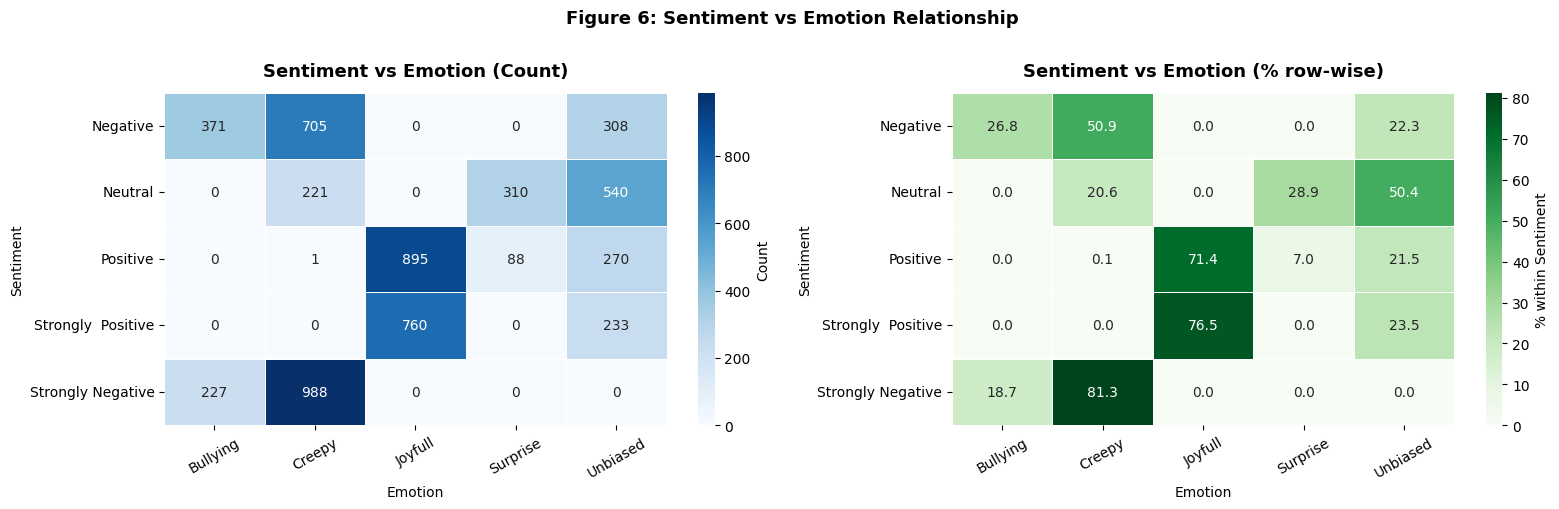

In [18]:
cross_tab = pd.crosstab(df['Sentiment'], df['Emotion'])
cross_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Sentiment vs Emotion (Count)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Sentiment')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(cross_pct.round(1), annot=True, fmt='.1f', cmap='Greens',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': '% within Sentiment'})
axes[1].set_title('Sentiment vs Emotion (% row-wise)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Sentiment')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)


plt.suptitle('')
fig.suptitle('Figure 6: Sentiment vs Emotion Relationship ', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sentiment_emotion_heatmap.png', bbox_inches='tight')
plt.show()

### 8. Sentiment vs Emotion Relationship

Figure 6 presents the relationship between sentiment and emotion classes through count-based and row-wise percentage heatmaps.

- **Negative** sentiment is predominantly associated with **Creepy** (50.9%) and **Bullying** (26.8%), with some overlap with **Unbiased** (22.3%).
- **Neutral** sentiment is mostly linked to **Unbiased** (50.4%) and **Surprise** (28.9%), with a minor presence of **Creepy** (20.6%).
- **Positive** sentiment strongly aligns with **Joyfull** (71.4%), followed by **Unbiased** (21.5%) and **Surprise** (7.0%).
- **Strongly Positive** sentiment is dominated by **Joyfull** (76.5%), with the remainder falling under **Unbiased** (23.5%).
- **Strongly Negative** sentiment is almost exclusively associated with **Creepy** (81.3%) and **Bullying** (18.7%), with no overlap with other emotion classes.

Overall, the heatmap reveals a strong and logical alignment between sentiment and emotion labels — positive sentiments map to joyful emotions, while negative sentiments correspond to creepy and bullying emotions. This consistency indicates that the two labels are semantically correlated, which may be leveraged during model training.

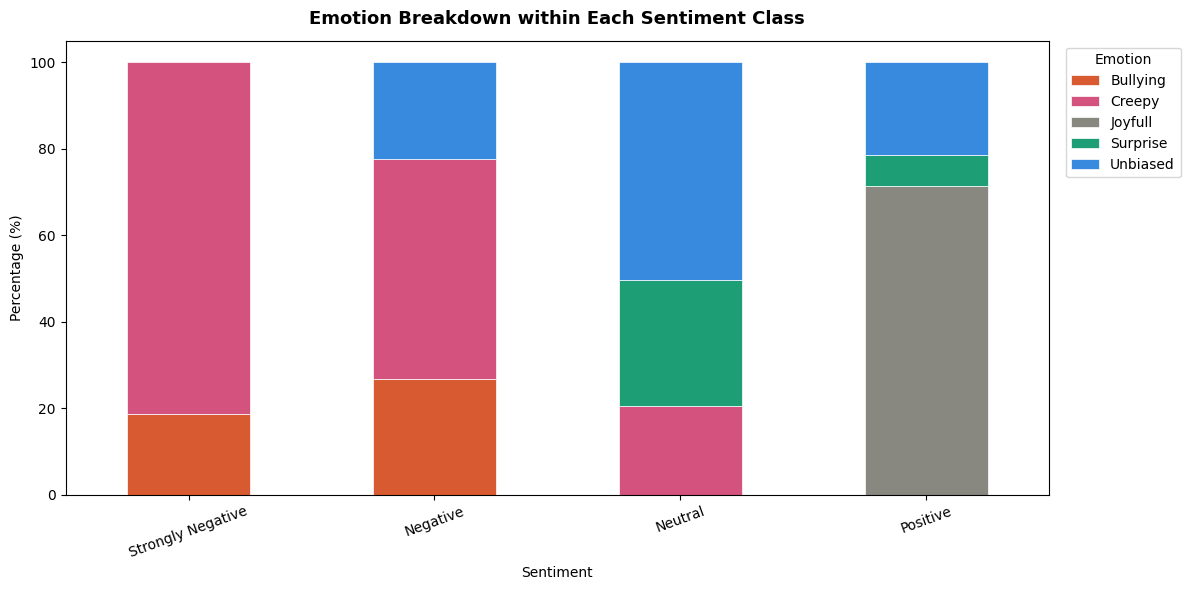

In [13]:
cross_pct = pd.crosstab(df['Sentiment'], df['Emotion'], normalize='index') * 100

sentiment_order = ['Strongly Negative','Negative','Neutral','Positive','Strongly Positive']
cross_pct = cross_pct.reindex([s for s in sentiment_order if s in cross_pct.index])

colors_stack = ['#D85A30','#D4537E','#888780','#1D9E75','#378ADD']
ax = cross_pct.plot(kind='bar', stacked=True, figsize=(12, 6),
                    color=colors_stack, edgecolor='white', linewidth=0.5)
plt.title('Emotion Breakdown within Each Sentiment Class', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Sentiment')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=20)
plt.legend(title='Emotion', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('stacked_bar.png', bbox_inches='tight')
plt.show()

### 9. Emotion Breakdown within Each Sentiment Class

The stacked bar chart illustrates the distribution of emotions
within each sentiment category.

- **Strongly Negative** sentiment is predominantly associated
with **Creepy** emotion (80%), with a smaller presence of
**Bullying** (20%).

- **Negative** sentiment is also largely driven by **Creepy**
(~50%), followed by **Bullying** (27%) and **Unbiased** (22%).

- **Neutral** sentiment shows a more diverse emotion breakdown,
with **Unbiased** (50%), **Surprise** (30%), and **Creepy**
(20%) — the most varied distribution among all sentiment classes.

- **Positive** sentiment is dominated by **Joyfull** (~70%),
followed by **Surprise** (8%) and **Unbiased** (22%).

**Key Insight:** Negative sentiments strongly correlate with
Creepy and Bullying emotions, while Positive sentiments align
with Joyfull — this confirms the dataset's labeling is
logically consistent.

## 10. Conclusion

This exploratory data analysis of the Bengali NLP Sentiment
and Emotion dataset reveals the following key findings:

- The dataset contains **5,917 unique texts** after removing
duplicates, annotated across **5 sentiment** and **5 emotion**
categories.
- **Emotion distribution is imbalanced** — Creepy (32.4%)
dominates while Surprise (6.7%) is underrepresented.
- **Sentiment distribution is relatively balanced** — ranging
from 16.8% to 23.4% across classes.
- Most texts are **short** (under 100 characters), typical of
social media data.
- **Strong semantic alignment** exists between sentiment and
emotion labels — negative sentiments map to Creepy/Bullying,
positive sentiments to Joyfull.

**Next Steps:** Text preprocessing (cleaning, normalization)
followed by machine learning model training for sentiment
and emotion classification.